In [ ]:
import pandas as pd
import pickle

In [45]:
df = pd.read_csv("C:\\Users\\chata\\Desktop\\Datasets\\DRUG REVIEW DATASET.csv",encoding='ISO-8859-1', on_bad_lines='skip')

In [46]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215063 entries, 0 to 215062
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     215063 non-null  int64 
 1   drugName     215063 non-null  object
 2   condition    213869 non-null  object
 3   review       215063 non-null  object
 4   rating       215063 non-null  int64 
 5   date         215063 non-null  object
 6   usefulCount  215063 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 11.5+ MB


In [48]:
# Filter out rows with missing values (nulls) in any of the columns
df = df.dropna()

In [49]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 213869 entries, 0 to 215062
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     213869 non-null  int64 
 1   drugName     213869 non-null  object
 2   condition    213869 non-null  object
 3   review       213869 non-null  object
 4   rating       213869 non-null  int64 
 5   date         213869 non-null  object
 6   usefulCount  213869 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 13.1+ MB


In [51]:
df = df.drop(columns=['uniqueID', 'date'])


In [52]:
df.head()

,drugName,condition,review,rating,usefulCount
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,27
1,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,192
2,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,17
3,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,10
4,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,37


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 213869 entries, 0 to 215062
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   drugName     213869 non-null  object
 1   condition    213869 non-null  object
 2   review       213869 non-null  object
 3   rating       213869 non-null  int64 
 4   usefulCount  213869 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 9.8+ MB


In [54]:
# Create the 'sentiment' column based on the 'rating' column
df['sentiment'] = df['rating'].apply(lambda x: 'positive' if x > 5 else 'negative')

# Drop the 'rating' column
#df_sampled = df_sampled.drop(columns=['rating'])

In [55]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 213869 entries, 0 to 215062
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   drugName     213869 non-null  object
 1   condition    213869 non-null  object
 2   review       213869 non-null  object
 3   rating       213869 non-null  int64 
 4   usefulCount  213869 non-null  int64 
 5   sentiment    213869 non-null  object
dtypes: int64(2), object(4)
memory usage: 11.4+ MB


,drugName,condition,review,rating,usefulCount,sentiment
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,27,positive
1,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,192,positive
2,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,17,negative
3,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,10,positive
4,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,37,positive


In [56]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 213869 entries, 0 to 215062
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   drugName     213869 non-null  object
 1   condition    213869 non-null  object
 2   review       213869 non-null  object
 3   rating       213869 non-null  int64 
 4   usefulCount  213869 non-null  int64 
 5   sentiment    213869 non-null  int32 
dtypes: int32(1), int64(2), object(3)
memory usage: 10.6+ MB


In [58]:
def review_clean(review):
    # changing to lower case
    lower = review.str.lower()

    # Replacing the repeating pattern of &#039;
    pattern_remove = lower.str.replace("&#039;", "")

    # Removing all the special Characters
    special_remove = pattern_remove.str.replace(r'[^\w\d\s]',' ')

    # Removing all the non ASCII characters
    ascii_remove = special_remove.str.replace(r'[^\x00-\x7F]+',' ')

    # Removing the leading and trailing Whitespaces
    whitespace_remove = ascii_remove.str.replace(r'^\s+|\s+?$','')

    # Replacing multiple Spaces with Single Space
    multiw_remove = whitespace_remove.str.replace(r'\s+',' ')

    # Replacing Two or more dots with one
    dataframe = multiw_remove.str.replace(r'\.{2,}', ' ')

    return dataframe
df['review'] = review_clean(df['review'])

In [59]:

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [60]:
# Splitting data into X (reviews) and y (sentiment)
X = df['review']  
y = df['sentiment']  

In [61]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [62]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [63]:
# Step 3: Train a Logistic Regression model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# Step 4: Evaluate the model (optional, for performance check)
y_pred = model.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.8362556693318371


In [64]:
filename = 'logistic_regression_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [65]:
from sklearn.metrics import classification_report, confusion_matrix

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.64      0.70     12773
           1       0.86      0.92      0.89     30001

    accuracy                           0.84     42774
   macro avg       0.82      0.78      0.79     42774
weighted avg       0.83      0.84      0.83     42774

Confusion Matrix:
[[ 8115  4658]
 [ 2346 27655]]


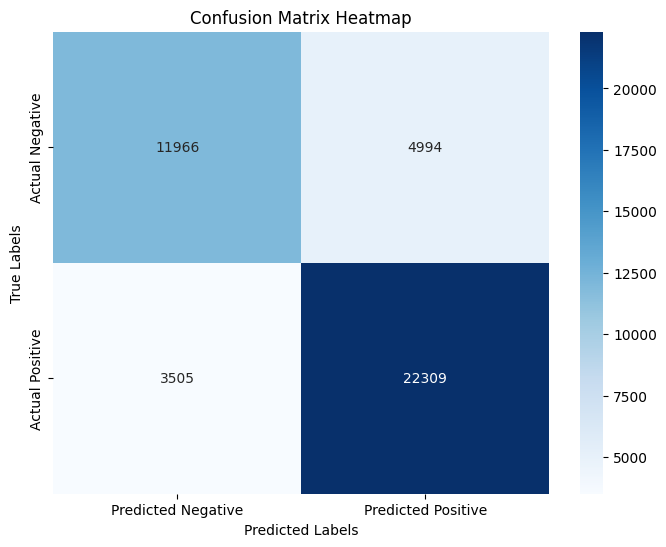

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix
conf_matrix = np.array([[11966, 4994],[ 3505, 22309]])

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')

# Show the plot
plt.show()

In [67]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion="gini", random_state=42,max_depth=3, min_samples_leaf=5)
classifier.fit(X_train_tfidf, y_train)
y_pred  =  classifier.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 71.62%


In [68]:
filename = 'Decision_Tree_model.sav'
pickle.dump(classifier, open(filename, 'wb'))

In [69]:
from sklearn.metrics import classification_report, confusion_matrix

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.09      0.16     12773
           1       0.72      0.98      0.83     30001

    accuracy                           0.72     42774
   macro avg       0.71      0.54      0.49     42774
weighted avg       0.71      0.72      0.63     42774

Confusion Matrix:
[[ 1140 11633]
 [  505 29496]]


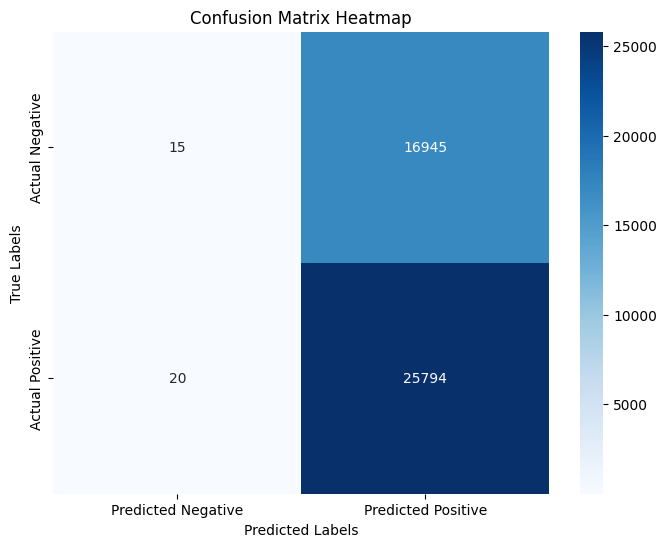

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix
conf_matrix = np.array([[15, 16945],[ 20, 25794]])

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')

# Show the plot
plt.show()

In [71]:
import xgboost as xgb
xg_model = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False)
xg_model.fit(X_train_tfidf, y_train)

# Predict and evaluate the model
y_pred = xg_model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')

C:\Users\chata\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\core.py:158: UserWarning: [18:54:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 82.14%


In [72]:
filename = 'Xgboost_model.sav'
pickle.dump(xg_model, open(filename, 'wb'))

In [73]:
from sklearn.metrics import classification_report, confusion_matrix

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.53      0.64     12773
           1       0.83      0.95      0.88     30001

    accuracy                           0.82     42774
   macro avg       0.82      0.74      0.76     42774
weighted avg       0.82      0.82      0.81     42774

Confusion Matrix:
[[ 6771  6002]
 [ 1638 28363]]


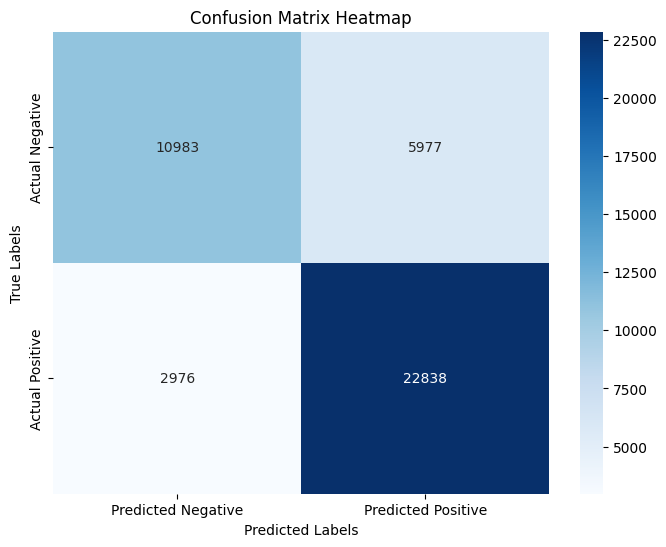

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix
conf_matrix = np.array([[10983, 5977],[ 2976, 22838]])

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')

# Show the plot
plt.show()

In [75]:
from sklearn.ensemble import RandomForestClassifier
# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predict and evaluate the model
y_pred = rf_model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 92.54%


In [76]:
filename = 'Random_Forest_model.sav'
pickle.dump(rf_model, open(filename, 'wb'))

In [77]:
from sklearn.metrics import classification_report, confusion_matrix

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.79      0.86     12773
           1       0.92      0.98      0.95     30001

    accuracy                           0.93     42774
   macro avg       0.93      0.89      0.91     42774
weighted avg       0.93      0.93      0.92     42774

Confusion Matrix:
[[10095  2678]
 [  514 29487]]


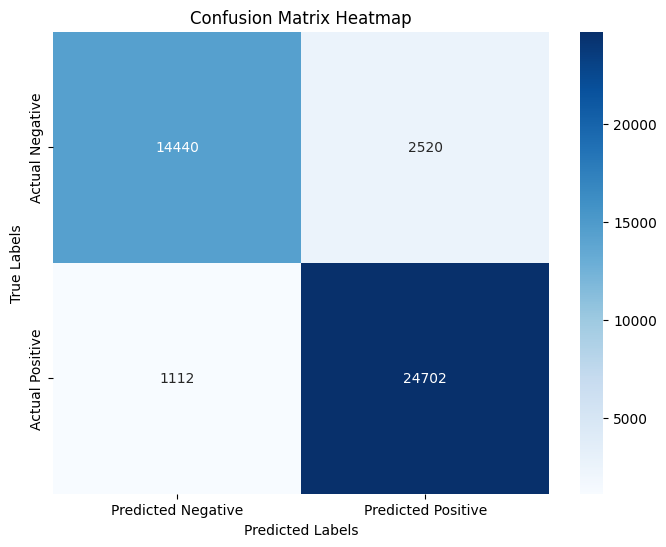

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix
conf_matrix = np.array([[14440, 2520],[ 1112, 24702]])

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')

# Show the plot
plt.show()

In [79]:
def predict_top_k_drugs(condition, k=3, alpha=0.5):
    # Filter dataset by condition
    condition_data = df[df['condition'].str.contains(condition, case=False, na=False)].copy()
    if condition_data.empty:
        return "No matching condition found in the dataset."

    # Get sentiment probability
    review_vectors = vectorizer.transform(condition_data['review'])
    sentiment_probs = rf_model.predict_proba(review_vectors)[:, 1]  # Probability of being positive
   # Normalize rating and usefulCount
    max_rating = condition_data['rating'].max()
    max_useful = condition_data['usefulCount'].max()

    condition_data['normalized_rating'] = condition_data['rating'] / max_rating if max_rating > 0 else 1
    condition_data['normalized_useful'] = condition_data['usefulCount'] / max_useful if max_useful > 0 else 1

    # Compute weighted sentiment score
    condition_data['weighted_sentiment'] = sentiment_probs * (
        alpha * condition_data['normalized_rating'] + (1 - alpha) * condition_data['normalized_useful']
    )

    # Get top K drugs
    top_k_drugs = (
        condition_data.groupby('drugName')['weighted_sentiment']
        .mean()
        .nlargest(k)
        .index.tolist()
    )

    return top_k_drugs


In [80]:
# Example usage
condition_input = "ADHD"
top_k_drugs = predict_top_k_drugs(condition_input, k=5, alpha=0.7)

print(f"Top 5 Drugs for {condition_input} based on sentiment analysis: {top_k_drugs}")

Top 5 Drugs for ADHD based on sentiment analysis: ['Provigil', 'Desoxyn', 'Dextrostat', 'ProCentra', 'Ritalin LA']
